In [1]:
# ---------------------------------------------------------------------------
# From prediction to decision: maintenance scheduling
# ---------------------------------------------------------------------------
# 02 ends with a predicted RUL per engine. A maintenance planner cannot act on
# that directly -- the question on their desk is "which engines go into the shop
# this week?", and the shop has limited capacity.
#
# This notebook turns the predictions into a schedule and, because we know the
# true RUL of the test engines, scores how good that schedule actually was.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ortools.sat.python import cp_model

predictions = pd.read_csv('../outputs/test_predictions.csv')
val_errors = pd.read_csv('../outputs/lstm_val_errors.csv')['d'].values

print("Engines:", len(predictions))
predictions.head()

Engines: 100


,unit,rul_true,rul_true_capped,pred_lr,pred_rf,pred_xgb,pred_lstm
0,1,112.0,112.0,124.866783,121.402574,123.350174,118.219120
1,2,98.0,98.0,100.570154,118.054569,115.516490,118.204030
2,3,69.0,69.0,74.814186,45.751687,52.164520,46.461636
3,4,82.0,82.0,76.370823,85.138481,76.643620,77.784280
4,5,91.0,91.0,89.683985,106.628567,107.303450,113.763610


In [2]:
# --- problem parameters -----------------------------------------------------
# HORIZON: how far ahead we are planning, in cycles.
# CAPACITY: engines the shop can service per cycle. This is what makes the
#   problem hard -- with unlimited capacity you would just service every engine
#   at the last safe moment and there would be nothing to optimise.
# FAILURE_COST vs WASTE_COST: an unplanned in-service failure costs 100x one
#   wasted cycle of remaining life. The asymmetry mirrors the NASA score, where
#   predicting late is punished far harder than predicting early.
HORIZON = 30
CAPACITY = 3
FAILURE_COST = 100
WASTE_COST = 1

rul_true = predictions['rul_true'].values
rul_pred = predictions['pred_lstm'].values
units = predictions['unit'].values

print("Slots available:", HORIZON * CAPACITY, "for", len(units), "engines")
print("Engines that truly fail within the horizon:", (rul_true <= HORIZON).sum())
print("Engines the LSTM thinks are critical:      ", (rul_pred <= HORIZON).sum())

Slots available: 90 for 100 engines
Engines that truly fail within the horizon: 25
Engines the LSTM thinks are critical:       24


In [3]:
def schedule_cost(rul_estimate, period):
    """Cost the optimiser believes it is paying, given its RUL estimate.

    period is None when the engine is deferred past this planning window.

    Being late still beats never being serviced, so the late branch keeps a term
    that grows with lateness. Without it the optimiser is indifferent between
    booking an overdue engine tomorrow and abandoning it, and it abandons.
    """
    if period is None:
        if rul_estimate > HORIZON:
            return 0                      # believed to survive the window
        return FAILURE_COST + int(round(HORIZON + 1 - rul_estimate)) * WASTE_COST
    if period <= rul_estimate:
        return int(round(rul_estimate - period)) * WASTE_COST   # life thrown away
    return FAILURE_COST + int(round(period - rul_estimate)) * WASTE_COST


def evaluate_schedule(schedule, rul_actual):
    """Score a schedule against the RUL that actually happened.

    schedule maps engine index -> period, or None if deferred.
    """
    failures, wasted = 0, 0
    for i, period in schedule.items():
        actual = rul_actual[i]
        if period is None:
            if actual <= HORIZON:
                failures += 1        # left in service and it broke
        elif period > actual:
            failures += 1            # shop slot came too late
        else:
            wasted += actual - period

    return {
        'failures': failures,
        'wasted_life': int(round(wasted)),
        'total_cost': failures * FAILURE_COST + int(round(wasted)) * WASTE_COST,
    }

In [4]:
def solve_schedule(rul_estimate, horizon=HORIZON, capacity=CAPACITY, verbose=False):
    """Exact maintenance schedule via CP-SAT.

    Decision variables x[i, t] = 1 when engine i is serviced in period t. Each
    engine is serviced at most once; leaving every x[i, t] at 0 means deferring
    it past the window, which the objective prices separately.
    """
    n = len(rul_estimate)
    model = cp_model.CpModel()

    x = {}
    for i in range(n):
        for t in range(1, horizon + 1):
            x[i, t] = model.NewBoolVar(f'x_{i}_{t}')

    # Each engine gets at most one shop slot.
    for i in range(n):
        model.Add(sum(x[i, t] for t in range(1, horizon + 1)) <= 1)

    # The shop cannot exceed its daily capacity.
    for t in range(1, horizon + 1):
        model.Add(sum(x[i, t] for i in range(n)) <= capacity)

    # Objective: cost of every slot actually taken, plus the deferral cost for
    # engines left unscheduled. (1 - sum_t x[i,t]) is 1 exactly when deferred.
    terms = []
    for i in range(n):
        for t in range(1, horizon + 1):
            terms.append(schedule_cost(rul_estimate[i], t) * x[i, t])
        deferred = 1 - sum(x[i, t] for t in range(1, horizon + 1))
        terms.append(schedule_cost(rul_estimate[i], None) * deferred)

    model.Minimize(sum(terms))

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 60.0
    status = solver.Solve(model)

    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        raise RuntimeError(f'no solution: {solver.StatusName(status)}')

    schedule = {}
    for i in range(n):
        schedule[i] = next(
            (t for t in range(1, horizon + 1) if solver.Value(x[i, t])), None
        )

    if verbose:
        print(f'  status={solver.StatusName(status)}  '
              f'planned cost={solver.ObjectiveValue():.0f}  '
              f'time={solver.WallTime():.2f}s')

    return schedule

In [5]:
# --- baseline 1: calendar-based preventive maintenance ----------------------
# The traditional approach: ignore condition data entirely and work through the
# fleet at a fixed rate. This is what predictive maintenance is meant to beat.
def fixed_interval_schedule(n, horizon=HORIZON, capacity=CAPACITY):
    schedule = {}
    for i in range(n):
        period = i // capacity + 1
        schedule[i] = period if period <= horizon else None
    return schedule


# --- baseline 2: greedy triage ----------------------------------------------
# What a planner would do with the predictions but no solver: deal with the most
# urgent engine first, and book each one as late as it can safely go so as not
# to waste life. Reasonable, and myopic -- it never reconsiders an earlier
# booking when a more urgent engine turns up later in the list.
def greedy_schedule(rul_estimate, horizon=HORIZON, capacity=CAPACITY):
    remaining = {t: capacity for t in range(1, horizon + 1)}
    schedule = {}

    for i in np.argsort(rul_estimate):          # most urgent first
        if rul_estimate[i] > horizon:
            schedule[i] = None                  # safe to defer
            continue

        latest = int(min(horizon, np.floor(rul_estimate[i])))
        chosen = next((t for t in range(max(latest, 1), 0, -1) if remaining[t] > 0), None)
        if chosen is None:                      # no safe slot left, take anything
            chosen = next((t for t in range(1, horizon + 1) if remaining[t] > 0), None)

        schedule[i] = chosen
        if chosen is not None:
            remaining[chosen] -= 1

    return schedule

In [6]:
# --- the safety margin ------------------------------------------------------
# Feeding raw predictions to the optimiser assumes they are exact. They are not:
# the LSTM's validation errors show a long tail of *late* predictions (d > 0),
# which are precisely the ones that get an engine scheduled after it has failed.
#
# The margin is read off the validation errors, never the test set -- otherwise
# we would be tuning the safety buffer on the data we report results on.
for q in [50, 75, 90, 95, 99]:
    print(f'  {q}th percentile of d: {np.percentile(val_errors, q):6.2f}')

# Chosen a priori as "cover 90% of the error distribution", NOT read off the
# test outcome -- the sweep further down is a diagnostic, not the selection.
SAFETY_QUANTILE = 90
safety_margin = np.percentile(val_errors, SAFETY_QUANTILE)

# Subtracting the margin makes the planner act as if every engine is closer to
# failure than the point estimate says.
rul_robust = np.maximum(rul_pred - safety_margin, 0)

print(f'\nSafety margin ({SAFETY_QUANTILE}th pct): {safety_margin:.2f} cycles')
print(f'Engines treated as critical after the margin: {(rul_robust <= HORIZON).sum()}'
      f'  (was {(rul_pred <= HORIZON).sum()})')

  50th percentile of d:  -0.42
  75th percentile of d:   7.93
  90th percentile of d:  19.15
  95th percentile of d:  27.89
  99th percentile of d:  40.90

Safety margin (90th pct): 19.15 cycles
Engines treated as critical after the margin: 30  (was 24)


In [7]:
# --- run every strategy -----------------------------------------------------
strategies = {}

strategies['Fixed interval'] = fixed_interval_schedule(len(units))
strategies['Greedy (LSTM)'] = greedy_schedule(rul_pred)

print('CP-SAT, raw predictions:')
strategies['CP-SAT (LSTM)'] = solve_schedule(rul_pred, verbose=True)

print('CP-SAT, safety margin:')
strategies['CP-SAT (LSTM + margin)'] = solve_schedule(rul_robust, verbose=True)

# Upper bound: what a planner with a perfect crystal ball would achieve. Not
# reachable, but it shows how much of the remaining gap is prediction error
# rather than bad scheduling.
print('CP-SAT, perfect information:')
strategies['CP-SAT (perfect info)'] = solve_schedule(rul_true, verbose=True)

results = pd.DataFrame([
    {'strategy': name, **evaluate_schedule(sched, rul_true)}
    for name, sched in strategies.items()
])
results['scheduled'] = [sum(1 for v in s.values() if v is not None) for s in strategies.values()]
results = results.sort_values('total_cost')
results

CP-SAT, raw predictions:
  status=OPTIMAL  planned cost=15  time=0.04s
CP-SAT, safety margin:
  status=OPTIMAL  planned cost=1155  time=0.02s
CP-SAT, perfect information:
  status=OPTIMAL  planned cost=1  time=0.02s


,strategy,failures,wasted_life,total_cost,scheduled
4,CP-SAT (perfect info),0,1,1,25
3,CP-SAT (LSTM + margin),0,435,435,30
1,Greedy (LSTM),15,38,1538,24
2,CP-SAT (LSTM),15,38,1538,24
0,Fixed interval,13,5512,6812,90


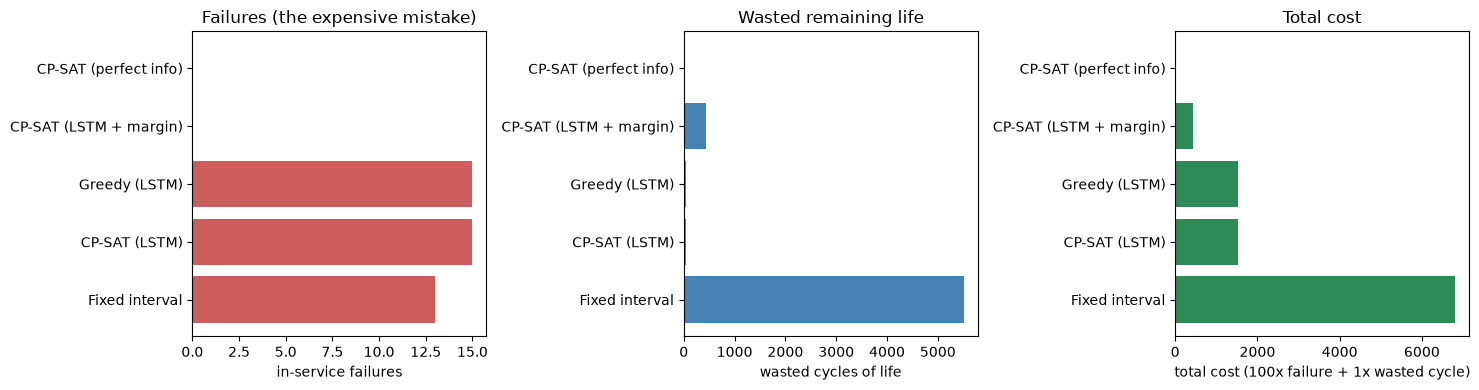

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

order = results['strategy'].tolist()

ax[0].barh(order, results['failures'], color='indianred')
ax[0].set_xlabel('in-service failures'); ax[0].invert_yaxis()
ax[0].set_title('Failures (the expensive mistake)')

ax[1].barh(order, results['wasted_life'], color='steelblue')
ax[1].set_xlabel('wasted cycles of life'); ax[1].invert_yaxis()
ax[1].set_title('Wasted remaining life')

ax[2].barh(order, results['total_cost'], color='seagreen')
ax[2].set_xlabel(f'total cost ({FAILURE_COST}x failure + 1x wasted cycle)')
ax[2].invert_yaxis()
ax[2].set_title('Total cost')

plt.tight_layout()
plt.show()

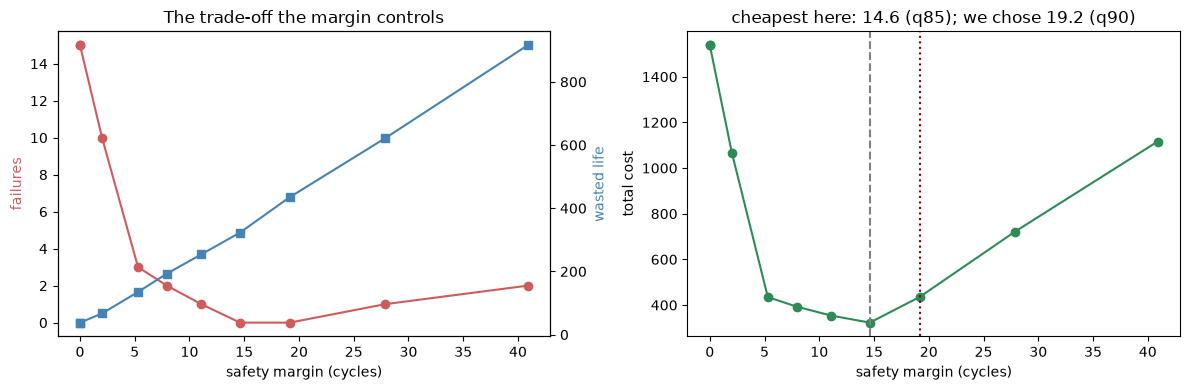

,quantile,margin,failures,wasted_life,total_cost
0,0,0.000000,15,38,1538
1,50,0.000000,15,38,1538
2,60,2.013166,10,67,1067
3,70,5.298002,3,135,435
4,75,7.933365,2,193,393
5,80,11.075943,1,254,354
6,85,14.613436,0,323,323
7,90,19.152405,0,435,435
8,95,27.889789,1,622,722
9,99,40.898365,2,916,1116


In [9]:
# --- how the margin trades failures against waste ---------------------------
# Larger margins pull maintenance forward: fewer engines fail, more life is
# thrown away. The optimum is wherever the two curves cross in cost terms, and
# it depends entirely on the failure/waste price ratio.
sweep = []
for q in [0, 50, 60, 70, 75, 80, 85, 90, 95, 99]:
    margin = max(np.percentile(val_errors, q), 0) if q > 0 else 0.0
    sched = solve_schedule(np.maximum(rul_pred - margin, 0))
    outcome = evaluate_schedule(sched, rul_true)
    sweep.append({'quantile': q, 'margin': margin, **outcome})

sweep_df = pd.DataFrame(sweep)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(sweep_df['margin'], sweep_df['failures'], 'o-', color='indianred', label='failures')
ax0b = ax[0].twinx()
ax0b.plot(sweep_df['margin'], sweep_df['wasted_life'], 's-', color='steelblue', label='wasted life')
ax[0].set_xlabel('safety margin (cycles)'); ax[0].set_ylabel('failures', color='indianred')
ax0b.set_ylabel('wasted life', color='steelblue')
ax[0].set_title('The trade-off the margin controls')

ax[1].plot(sweep_df['margin'], sweep_df['total_cost'], 'o-', color='seagreen')
best = sweep_df.loc[sweep_df['total_cost'].idxmin()]
ax[1].axvline(best['margin'], linestyle='--', color='grey')
ax[1].set_xlabel('safety margin (cycles)'); ax[1].set_ylabel('total cost')
ax[1].axvline(safety_margin, linestyle=':', color='darkred')
ax[1].set_title(f"cheapest here: {best['margin']:.1f} (q{int(best['quantile'])}); we chose {safety_margin:.1f} (q{SAFETY_QUANTILE})")

plt.tight_layout()
plt.show()

sweep_df

In [10]:
# --- does the ranking survive a different price ratio? ----------------------
# FAILURE_COST = 100 was an assumption. If failures are only 20x a wasted cycle,
# or 500x, does optimisation still pay off? Re-scoring the same schedules under
# different ratios keeps this honest.
ratio_rows = []
for fc in [20, 50, 100, 200, 500]:
    for name, sched in strategies.items():
        outcome = evaluate_schedule(sched, rul_true)
        ratio_rows.append({
            'failure_cost': fc,
            'strategy': name,
            'total_cost': outcome['failures'] * fc + outcome['wasted_life'],
        })

ratio_df = pd.DataFrame(ratio_rows).pivot(
    index='strategy', columns='failure_cost', values='total_cost'
)
ratio_df.loc[results['strategy']]

failure_cost,20,50,100,200,500
strategy,,,,,
CP-SAT (perfect info),1,1,1,1,1
CP-SAT (LSTM + margin),435,435,435,435,435
Greedy (LSTM),338,788,1538,3038,7538
CP-SAT (LSTM),338,788,1538,3038,7538
Fixed interval,5772,6162,6812,8112,12012
